In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tqdm.notebook import tqdm

# Set device - GPU is highly recommended for 30k images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Extraction logic
zip_path = 'dataset.zip'
extract_dir = './dataset'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Using device: cuda
Dataset already extracted.


In [2]:
class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort']
        self.file_list = []
        
        for idx, cls_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, cls_name)
            if not os.path.exists(class_path): continue
            for f in os.listdir(class_path):
                if f.endswith('.npy'):
                    self.file_list.append((os.path.join(class_path, f), idx))

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path, label = self.file_list[idx]
        
        img_array = np.load(file_path).astype(np.float32)
        
        if img_array.ndim == 3:
            img_array = np.squeeze(img_array)
        
        img = torch.from_numpy(img_array).unsqueeze(0)
        
        img = img.repeat(3, 1, 1)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

In [3]:
train_dir = './dataset/dataset/train'
val_dir = './dataset/dataset/val'

# Augmentation for training; basic normalization for validation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180) 
])

train_set = LensingDataset(train_dir, transform=train_transform)
val_set = LensingDataset(val_dir)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)

print(f"Training on {len(train_set)} samples.")
print(f"Validating on {len(val_set)} samples.")

Training on 30000 samples.
Validating on 7500 samples.


In [4]:
# Load pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Adjust the final layer for 3-class output (no, sphere, vort)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Lower LR for fine-tuning

In [5]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")
    
    for i, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Calculate statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        current_acc = 100. * correct / total
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}', 
            'acc': f'{current_acc:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    print(f'>> Epoch {epoch+1} Summary: Avg Loss: {epoch_loss:.4f} | Final Acc: {current_acc:.2f}%')

Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

>> Epoch 1 Summary: Avg Loss: 0.9987 | Final Acc: 46.82%


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

>> Epoch 2 Summary: Avg Loss: 0.6719 | Final Acc: 70.34%


Epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

...

>> Epoch 8 Summary: Avg Loss: 0.3537 | Final Acc: 86.15%


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

>> Epoch 9 Summary: Avg Loss: 0.3429 | Final Acc: 86.79%


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

>> Epoch 10 Summary: Avg Loss: 0.3241 | Final Acc: 87.54%


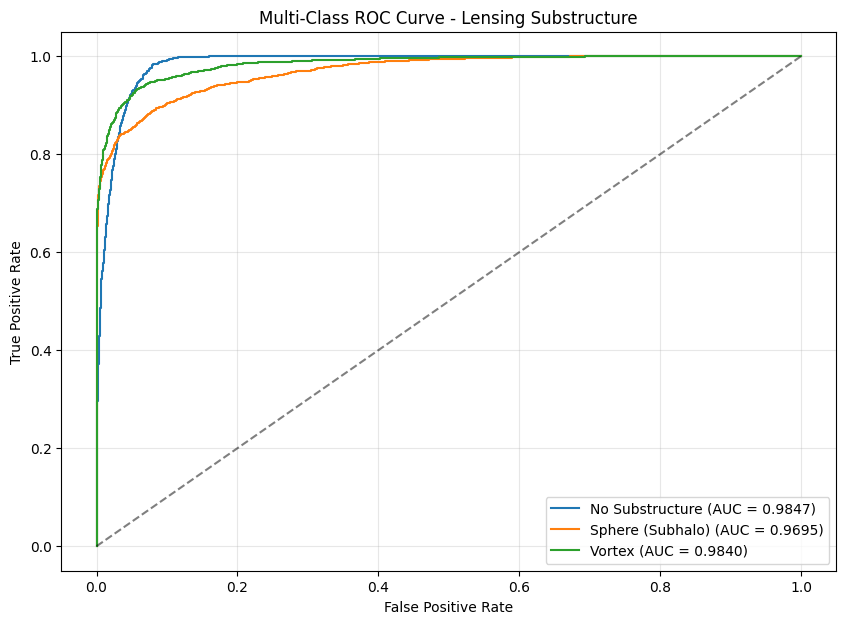

Final Macro-Average AUC: 0.9794


In [6]:
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# Calculate and Plot ROC
plt.figure(figsize=(10, 7))
class_map = {0: 'No Substructure', 1: 'Sphere (Subhalo)', 2: 'Vortex'}

for i in range(3):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_map[i]} (AUC = {score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve - Lensing Substructure')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

macro_auc = roc_auc_score(all_labels_bin, all_probs, average='macro', multi_class='ovr')
print(f"Final Macro-Average AUC: {macro_auc:.4f}")

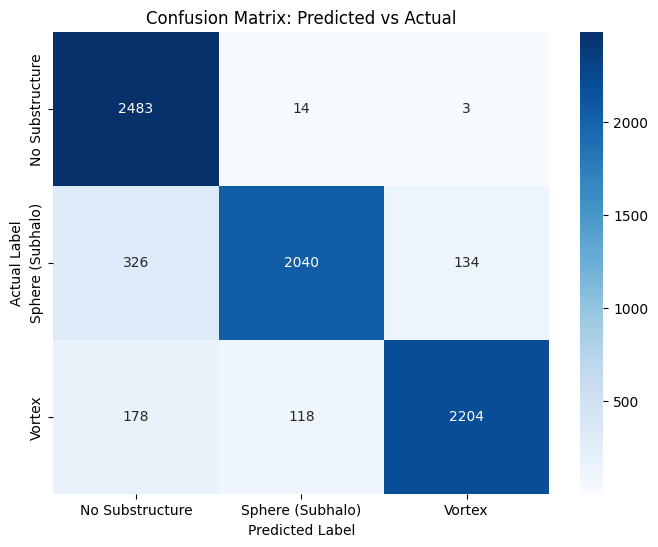

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Create the matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_map.values(), 
            yticklabels=class_map.values())
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()